Extract text from image using tesseract

https://github.com/UB-Mannheim/tesseract/wiki


https://github.com/tesseract-ocr/tesseract?tab=readme-ov-file#installing-tesseract


https://github.com/tesseract-ocr/tessdata/blob/main/vie.traineddata

In [48]:
import cv2
import pytesseract
import os
import numpy as np
import matplotlib.pyplot as plt

current_folder = "\\".join(os.getcwd().split("\\")[:-1])

Setup Voice Engine

In [50]:
def load_image_from_path(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error loading image: {image_path}")
        return None

    return image

In [51]:
def preprocess_image(image):
    # Noise reduction using Gaussian Blur
    denoised_image = cv2.GaussianBlur(image, (5, 5), 0)

    # Sharpening the image
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    sharpened_image = cv2.filter2D(denoised_image, -1, kernel)

    return sharpened_image

In [52]:
def extract_text_from_image(img):
    """
    Extracts text from an image using OpenCV and Tesseract OCR.

    Args:
      image_path: Path to the image file.

    Returns:
      Extracted text from the image.
    """

    try:
        img_copy = img.copy()

        # Preprocess the image (optional)
        gray_img_copy = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
        gray_img_copy = preprocess_image(gray_img_copy)
        _, thresh = cv2.threshold(gray_img_copy, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Perform OCR with Vietnamese language support
        custom_config = r"--oem 3 --psm 6 -l vie"  # Use LSTM OCR engine and page segmentation mode 6
        text = pytesseract.image_to_string(thresh, config=custom_config)

        return text

    except Exception as e:
        print(f"Error extracting text: {e}")
        return None

In [53]:
def extract_zone(img, x1, y1, x2, y2):
    """
    Extracts a specific zone from an image.

    Args:
      image_path: Path to the image file.
      x1, y1: Top-left coordinates of the zone.
      x2, y2: Bottom-right coordinates of the zone.

    Returns:
      The extracted image as a NumPy array.
    """
    try:
        # Ensure coordinates are within bounds
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(x2, img.shape[1])
        y2 = min(y2, img.shape[0])

        # Extract the region of interest (ROI)
        extracted_zone = img[y1:y2, x1:x2]

        return extracted_zone
    except Exception as e:
        print(f"Error extracting zone: {e}")
        return None

Load image to opencv processor

In [54]:
image = load_image_from_path(os.path.join(current_folder, "images", "template", "template.png"))

Extract subset from original image

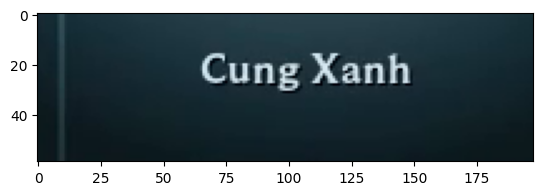

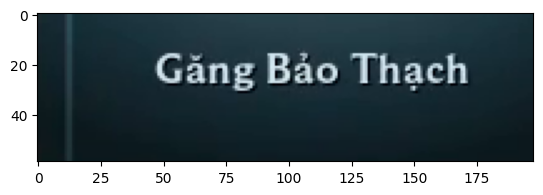

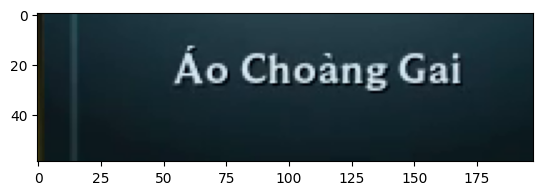

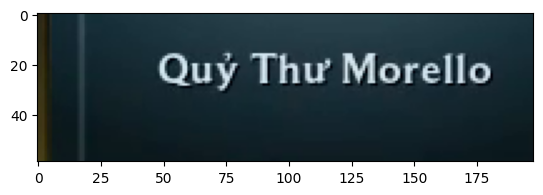

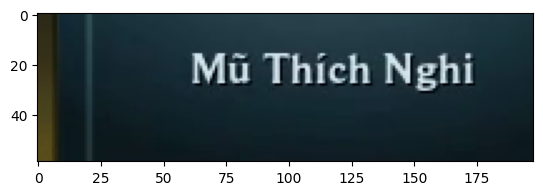

In [78]:
subset_images = []
box_width = 198
box_height = 59
x1 = 293
y1 = 984
x2 = x1 + box_width
y2 = y1 + box_height
offset = 235
i = 1
while i <= 5:
    if i > 1:
        x1 = x1 + offset
        x2 = x1 + box_width
    result = extract_zone(image, x1, y1, x2, y2)

    if result is not None:
        subset_images.append(result)
        plt.imshow(result, cmap="gray")
        plt.show()
    else:
        print(f"Error extracting zone {i}")
    i += 1

In [ ]:
# Example usage
for subset_image in subset_images:
    extracted_text = extract_text_from_image(subset_image)


    if extracted_text:

        print("Extracted Text:\n", extracted_text)

    else:

        print("Failed to extract text.")

Extracted Text:
 Cung Xanh

Extracted Text:
 Gáng Bảo Thạch

Extracted Text:
 Áo Choáng Gai

Extracted Text:
 Quỷ Thư Morello

Extracted Text:
 Mùũ Thích Nghi

